# Bab 3 — Statistical Experiments and Significance Testing

**Desain eksperimen** adalah pilar praktik statistik. Tujuannya: mengonfirmasi atau menolak sebuah hipotesis. Alur umumnya:

> Rumuskan hipotesis → Desain eksperimen → Kumpulkan data → Inferensi / kesimpulan

Isi notebook:
1. A/B testing
2. Hypothesis test
3. Resampling & permutation test
4. Statistical significance & p-value
5. t-test
6. Multiple testing
7. Degrees of freedom
8. ANOVA
9. Chi-square test & Fisher's exact test
10. Multi-arm bandit
11. Power & sample size

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats import power

%matplotlib inline
sns.set_theme(style='whitegrid')
rng = np.random.default_rng(seed=1)

DATA_URL = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/'

def load(name, **kwargs):
    local = Path('data') / name
    source = local if local.exists() else DATA_URL + name
    return pd.read_csv(source, **kwargs)

## 1. A/B Testing

**A/B test** adalah eksperimen dengan dua grup untuk menentukan mana dari dua *treatment* (produk, prosedur, desain halaman web, harga) yang lebih baik. Biasanya salah satunya adalah treatment standar (atau tanpa treatment) yang disebut **control**.

- **Treatment** — sesuatu (obat, harga, headline web) yang diberikan kepada subjek.
- **Treatment group** — kelompok subjek yang menerima treatment tertentu.
- **Control group** — kelompok yang menerima treatment standar atau tanpa treatment.
- **Randomization** — proses menempatkan subjek ke treatment secara **acak**. Ini kunci agar perbedaan hasil bisa diatribusikan ke treatment, bukan ke faktor lain.
- **Subject** — item (pengunjung web, pasien) yang diberi treatment.
- **Test statistic** — metrik yang dipakai untuk mengukur efek treatment (misal: conversion rate, rata-rata waktu di halaman).

**Blind study**: subjek tidak tahu treatment apa yang diterima. **Double-blind**: peneliti juga tidak tahu.

Metrik harus ditentukan **sebelum** eksperimen dimulai untuk menghindari bias peneliti.

## 2. Hypothesis Test (Significance Test)

Tujuan uji hipotesis: membantu kita mengetahui apakah efek yang teramati bisa jadi **hanya karena kebetulan acak**. Manusia cenderung meremehkan keacakan dan melihat pola di mana-mana.

- **Null hypothesis ($H_0$)** — hipotesis bahwa hasil yang diamati hanya karena kebetulan (tidak ada efek).
- **Alternative hypothesis ($H_A$)** — kebalikan dari null (yang ingin kita buktikan).
- **One-way test (one-tailed)** — uji hipotesis yang hanya menghitung kejadian kebetulan ke **satu arah** (misal: B lebih baik dari A).
- **Two-way test (two-tailed)** — uji yang menghitung kejadian kebetulan ke **dua arah** (A ≠ B).

Logikanya mirip pengadilan: $H_0$ dianggap benar ("tidak bersalah") sampai bukti cukup kuat untuk menolaknya.

## 3. Resampling & Permutation Test

**Resampling** berarti mengambil sampel berulang dari data observasi untuk menilai variabilitas acak sebuah statistik. Ada dua jenis utama: **bootstrap** (Bab 2) dan **permutation test**.

**Permutation test** (*randomization test*): gabungkan semua data dari grup A dan B, acak ulang (*shuffle*), lalu bagi lagi menjadi grup berukuran sama seperti aslinya. Jika $H_0$ benar (treatment tidak berpengaruh), label grup tidak penting, sehingga perbedaan yang diamati seharusnya mirip dengan perbedaan hasil pengacakan.

Algoritma:
1. Gabungkan hasil semua grup menjadi satu dataset.
2. Acak, lalu ambil (tanpa pengembalian) sampel berukuran sama dengan grup A.
3. Dari sisa data, ambil sampel berukuran sama dengan grup B.
4. Hitung statistik (misal selisih mean) dari sampel-sampel tersebut.
5. Ulangi R kali → didapat **permutation distribution**.
6. Jika selisih yang diamati berada **di luar** sebagian besar permutation distribution, maka hasil tersebut **signifikan secara statistik**.

Contoh: *web stickiness* — apakah halaman B membuat pengunjung bertahan lebih lama dibanding halaman A? Data `web_page_data.csv` berisi durasi sesi (dalam ratusan detik).

        count        mean         std   min   25%    50%    75%    max
Page                                                                  
Page A   21.0  126.333333   88.463175  21.0  67.0   95.0  173.0  342.0
Page B   15.0  162.000000  101.136400  43.0  80.0  147.0  234.5  357.0


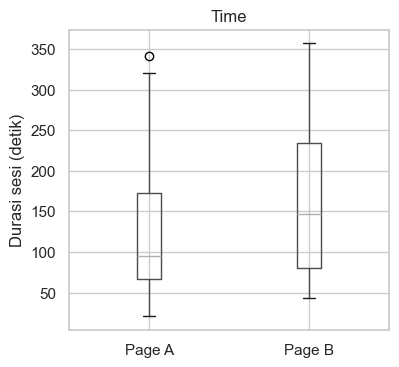

In [2]:
session_times = load('web_page_data.csv')
session_times['Time'] = 100 * session_times['Time']   # konversi ke detik
print(session_times.groupby('Page')['Time'].describe())

ax = session_times.boxplot(by='Page', column='Time', figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Durasi sesi (detik)')
plt.suptitle('')
plt.show()

Selisih mean yang diamati (B - A): 35.67 detik


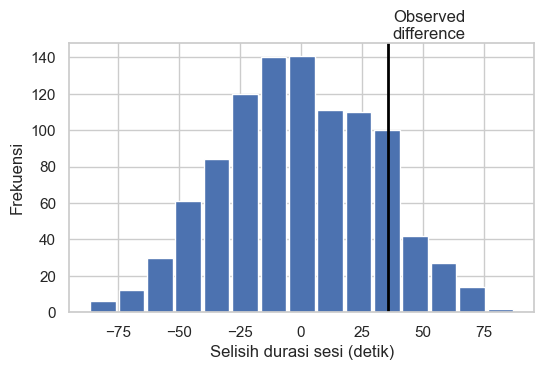

p-value (one-way): 0.127


In [3]:
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
observed_diff = mean_b - mean_a
print(f'Selisih mean yang diamati (B - A): {observed_diff:.2f} detik')

def perm_fun(x, n_a, n_b):
    """Acak ulang data gabungan, lalu hitung mean(B) - mean(A)."""
    shuffled = rng.permutation(x)
    return shuffled[n_a:n_a + n_b].mean() - shuffled[:n_a].mean()

n_a = (session_times.Page == 'Page A').sum()
n_b = (session_times.Page == 'Page B').sum()
perm_diffs = np.array([perm_fun(session_times.Time.to_numpy(), n_a, n_b) for _ in range(1000)])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(perm_diffs, bins=15, rwidth=0.9)
ax.axvline(observed_diff, color='black', lw=2)
ax.text(observed_diff + 2, 150, 'Observed\ndifference')
ax.set_xlabel('Selisih durasi sesi (detik)')
ax.set_ylabel('Frekuensi')
plt.show()

print('p-value (one-way):', np.mean(perm_diffs > observed_diff))

Sekitar 12–15% permutasi acak menghasilkan selisih ≥ selisih observasi. Artinya perbedaan waktu sesi antara halaman A dan B **masih dalam jangkauan variasi acak** → **tidak signifikan** secara statistik.

Variasi lain: **exhaustive permutation test** (mencoba semua kemungkinan pembagian, hanya untuk data kecil) dan **bootstrap permutation test** (penarikan dengan pengembalian).

## 4. Statistical Significance & p-Value

**Statistical significance** adalah cara mengukur apakah hasil eksperimen lebih ekstrem daripada yang bisa dihasilkan oleh kebetulan.

- **p-value** — *probabilitas memperoleh hasil seekstrem (atau lebih ekstrem dari) hasil observasi, jika null hypothesis benar*.
- **Alpha (α)** — ambang batas probabilitas yang harus dilewati agar hasil dianggap signifikan (umumnya 5% atau 1%).
- **Type 1 error** — menyimpulkan ada efek padahal sebenarnya tidak ada (**false positive**).
- **Type 2 error** — menyimpulkan tidak ada efek padahal sebenarnya ada (**false negative**).

⚠️ **Kesalahpahaman umum**: p-value **bukan** probabilitas bahwa hasilnya karena kebetulan, dan **bukan** probabilitas bahwa $H_0$ benar. *American Statistical Association* (2016) menegaskan bahwa p-value saja tidak mengukur besar efek atau pentingnya sebuah hasil.

### Contoh: e-commerce price test
| | Harga A | Harga B |
|---|---|---|
| Conversion | 200 | 182 |
| No conversion | 23.539 | 22.406 |

Harga A menghasilkan konversi ~5% lebih tinggi. Apakah ini signifikan?

Selisih conversion rate yang diamati: 0.0368%


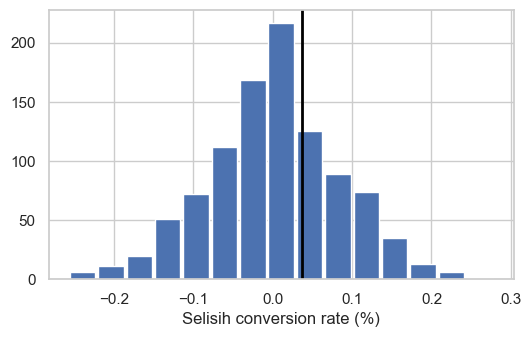

p-value (permutation): 0.306


In [4]:
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Selisih conversion rate yang diamati: {obs_pct_diff:.4f}%')

conversion = np.array([0] * 45945 + [1] * 382)
perm_diffs = np.array([100 * perm_fun(conversion, 23739, 22588) for _ in range(1000)])
# perm_fun menghitung B - A, sedangkan observasi A - B -> balik tanda
perm_diffs = -perm_diffs

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(perm_diffs, bins=15, rwidth=0.9)
ax.axvline(obs_pct_diff, color='black', lw=2)
ax.set_xlabel('Selisih conversion rate (%)')
plt.show()

print('p-value (permutation):', np.mean(perm_diffs > obs_pct_diff))

In [5]:
# Pendekatan formula: chi-square test (distribusi normal sebagai aproksimasi binomial)
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)
print(f'p-value dua sisi : {p_value:.4f}')
print(f'p-value satu sisi: {p_value / 2:.4f}')

p-value dua sisi : 0.6996
p-value satu sisi: 0.3498


p-value satu sisi ≈ 0.3 (permutation) sampai 0.35 (chi-square), jauh di atas α = 0.05 → perbedaan ini **tidak signifikan**; bisa saja hanya kebetulan.

## 5. t-Test

Sebelum era komputer, permutation test tidak praktis. Maka digunakan **t-test** yang didasarkan pada **distribusi t** (Bab 2) sebagai aproksimasi permutation distribution.

- **Test statistic** — metrik untuk selisih/efek yang diamati.
- **t-statistic** — versi *standardized* dari test statistic umum seperti mean:

$$t = \frac{\bar{x}_B - \bar{x}_A}{\sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}}}$$

- **t-distribution** — distribusi acuan (dari $H_0$) yang dipakai untuk membandingkan t-statistic.

Opsi `equal_var=False` menjalankan **Welch's t-test** yang tidak mengasumsikan varians kedua grup sama (lebih aman).

In [6]:
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time,
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False)
print(f't-statistic      : {res.statistic:.4f}')
print(f'p-value dua sisi : {res.pvalue:.4f}')
print(f'p-value satu sisi: {res.pvalue / 2:.4f}   (bandingkan dgn permutation test di atas)')

t-statistic      : -1.0983
p-value dua sisi : 0.2815
p-value satu sisi: 0.1408   (bandingkan dgn permutation test di atas)


## 6. Multiple Testing

> *Torture the data long enough, and it will confess.*

Jika kita melakukan 20 uji statistik dengan α = 0.05 dan **tidak ada efek sama sekali**, probabilitas **minimal satu** hasil signifikan secara kebetulan adalah:

$$1 - 0.95^{20} \approx 0.64$$

Masalah ini disebut **alpha inflation**. Istilah terkait:
- **Type 1 error** — keliru menyimpulkan efek signifikan.
- **False discovery rate (FDR)** — tingkat Type 1 error di antara banyak uji.
- **Adjustment of p-values** — koreksi untuk banyak uji pada data yang sama.
- **Overfitting** — model yang ikut mempelajari noise.

Koreksi umum:
- **Bonferroni** — bagi α dengan jumlah uji (sangat konservatif).
- **Holm** / **Benjamini–Hochberg (FDR)** — lebih seimbang.

Dalam predictive modeling, risiko ini dikurangi dengan **cross-validation** dan **holdout set**.

In [7]:
print('P(min. 1 false positive dari 20 uji):', round(1 - 0.95 ** 20, 3))

# Simulasi: 20 uji t pada data yang TIDAK punya efek sama sekali
pvals = np.array([stats.ttest_ind(rng.normal(size=50), rng.normal(size=50)).pvalue
                  for _ in range(20)])
print('p-value < 0.05 tanpa koreksi:', (pvals < 0.05).sum())

for method in ['bonferroni', 'holm', 'fdr_bh']:
    reject, p_adj, _, _ = multipletests(pvals, alpha=0.05, method=method)
    print(f'{method:10s}: signifikan setelah koreksi = {reject.sum()}')

P(min. 1 false positive dari 20 uji): 0.642
p-value < 0.05 tanpa koreksi: 1
bonferroni: signifikan setelah koreksi = 0
holm      : signifikan setelah koreksi = 0
fdr_bh    : signifikan setelah koreksi = 0


## 7. Degrees of Freedom

**Degrees of freedom (d.f.)** adalah jumlah nilai yang **bebas bervariasi** dalam perhitungan sebuah statistik. Contoh: jika kita tahu mean dari 10 nilai, dan sudah tahu 9 nilainya, nilai ke-10 **pasti** bisa dihitung → hanya 9 yang bebas. Karena itu varians sampel dibagi **n − 1**.

Pentingnya bagi data science: saat membuat **dummy variable** untuk regresi, variabel kategorikal dengan *k* kategori cukup diwakili *k − 1* kolom. Kalau memakai *k* kolom (plus intercept), terjadi **multicollinearity** sempurna dan regresi gagal.

In [8]:
hari = pd.DataFrame({'hari': ['Senin', 'Selasa', 'Rabu', 'Senin', 'Rabu']})
print('k kolom dummy:')
print(pd.get_dummies(hari, dtype=int))
print('k-1 kolom dummy (drop_first=True):')
print(pd.get_dummies(hari, drop_first=True, dtype=int))

k kolom dummy:
   hari_Rabu  hari_Selasa  hari_Senin
0          0            0           1
1          0            1           0
2          1            0           0
3          0            0           1
4          1            0           0
k-1 kolom dummy (drop_first=True):
   hari_Selasa  hari_Senin
0            0           1
1            1           0
2            0           0
3            0           1
4            0           0


## 8. ANOVA (Analysis of Variance)

Bagaimana kalau kita ingin membandingkan **lebih dari dua** grup sekaligus? Melakukan banyak uji berpasangan (A vs B, A vs C, ...) akan menimbulkan masalah multiple testing. **ANOVA** menguji secara keseluruhan: *apakah semua grup punya mean yang sama?*

- **Pairwise comparison** — uji hipotesis antara dua grup di antara banyak grup.
- **Omnibus test** — satu uji untuk varians keseluruhan di antara banyak mean grup.
- **Decomposition of variance** — memisahkan kontribusi komponen (efek keseluruhan, efek treatment, residual error).
- **F-statistic** — rasio varians antar mean grup terhadap varians di dalam grup:

$$F = \frac{\text{variance between groups}}{\text{variance within groups}} = \frac{MS_{treatment}}{MS_{error}}$$

- **SS (sum of squares)** — jumlah kuadrat deviasi dari suatu rata-rata.

Contoh: `four_sessions.csv` — durasi sesi di **4 halaman web** berbeda.

Page
Page 1    172.8
Page 2    182.6
Page 3    175.6
Page 4    164.6
Name: Time, dtype: float64


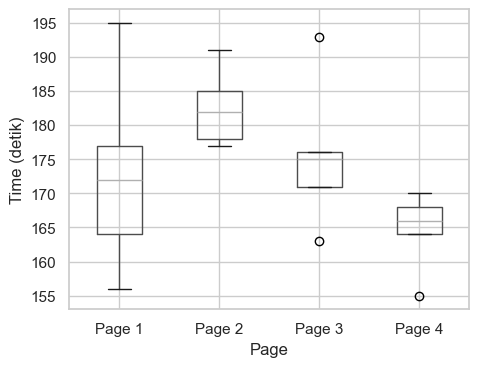

In [9]:
four_sessions = load('four_sessions.csv')
print(four_sessions.groupby('Page')['Time'].mean())

ax = four_sessions.boxplot(by='Page', column='Time', figsize=(5, 4))
ax.set_xlabel('Page')
ax.set_ylabel('Time (detik)')
plt.suptitle('')
plt.title('')
plt.show()

Observed variance of means: 55.43


Pr(Prob) permutation: 0.08333333333333333


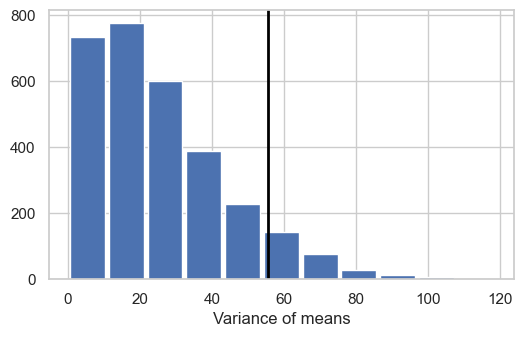

In [10]:
# ANOVA dengan permutation test
observed_variance = four_sessions.groupby('Page')['Time'].mean().var()
print('Observed variance of means:', round(observed_variance, 2))

def perm_test(df):
    df = df.copy()
    df['Time'] = rng.permutation(df['Time'].to_numpy())
    return df.groupby('Page')['Time'].mean().var()

perm_variance = np.array([perm_test(four_sessions) for _ in range(3000)])
print('Pr(Prob) permutation:', np.mean(perm_variance > observed_variance))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(observed_variance, color='black', lw=2)
ax.set_xlabel('Variance of means')
plt.show()

In [11]:
# ANOVA klasik dengan F-statistic (statsmodels)
model = smf.ols('Time ~ Page', data=four_sessions).fit()
aov_table = sm.stats.anova_lm(model)
print(aov_table)

# Alternatif singkat dengan scipy
groups = [g['Time'].to_numpy() for _, g in four_sessions.groupby('Page')]
print(stats.f_oneway(*groups))

            df  sum_sq     mean_sq         F    PR(>F)
Page       3.0   831.4  277.133333  2.739825  0.077586
Residual  16.0  1618.4  101.150000       NaN       NaN
F_onewayResult(statistic=np.float64(2.739825341901467), pvalue=np.float64(0.07758621525801461))


p-value ≈ 0.08 → pada α = 0.05 kita **belum bisa** menolak $H_0$ bahwa keempat halaman punya rata-rata durasi yang sama.

**Two-way ANOVA**: jika ada dua faktor (misal halaman × hari kerja/akhir pekan), kita bisa menguji efek masing-masing faktor dan **interaksinya**, contoh formula `Time ~ Page * Weekend`.

## 9. Chi-Square Test

**Chi-square test** dipakai untuk data **count** (hitungan) dalam tabel kontingensi, untuk menguji apakah distribusi hasil sesuai dengan ekspektasi di bawah asumsi **independence** (tidak ada hubungan).

- **Chi-square statistic** — ukuran sejauh mana data observasi menyimpang dari ekspektasi.
- **Expectation / expected** — hasil yang diharapkan jika $H_0$ benar.
- **Pearson residual**: $R = \frac{\text{Observed} - \text{Expected}}{\sqrt{\text{Expected}}}$, dan $\chi^2 = \sum R^2$.

Contoh: `click_rates.csv` — tiga headline (A, B, C) diuji; masing-masing ditampilkan ke 1.000 pengunjung. Apakah jumlah klik berbeda secara signifikan?

In [12]:
click_rate = load('click_rates.csv')
clicks = click_rate.pivot(index='Click', columns='Headline', values='Rate')
print(clicks, end='\n\n')

# Expected di bawah H0: semua headline punya click rate sama
row_average = clicks.mean(axis=1)
expected = pd.DataFrame({c: row_average for c in clicks.columns})
print('Expected:')
print(expected, end='\n\n')
print('Pearson residual:')
print(((clicks - expected) / np.sqrt(expected)).round(3))

Headline  Headline A  Headline B  Headline C
Click                                       
Click             14           8          12
No-click         986         992         988

Expected:
          Headline A  Headline B  Headline C
Click                                       
Click      11.333333   11.333333   11.333333
No-click  988.666667  988.666667  988.666667

Pearson residual:
Headline  Headline A  Headline B  Headline C
Click                                       
Click          0.792      -0.990       0.198
No-click      -0.085       0.106      -0.021


In [13]:
# Chi-square test dengan resampling (permutation)
def chi2_stat(observed, expected):
    return (((observed - expected) ** 2) / expected).to_numpy().sum()

chi2observed = chi2_stat(clicks, expected)

def perm_chi2(box):
    shuffled = rng.permutation(box)
    sample_clicks = [shuffled[:1000].sum(), shuffled[1000:2000].sum(), shuffled[2000:].sum()]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2_stat(pd.DataFrame([sample_clicks, sample_noclicks]), expected.to_numpy())

n_click = int(clicks.loc['Click'].sum())
n_noclick = int(clicks.loc['No-click'].sum())
box = np.array([1] * n_click + [0] * n_noclick)
perm_chi2_vals = np.array([perm_chi2(box) for _ in range(2000)])
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {np.mean(perm_chi2_vals > chi2observed):.4f}')

# Pendekatan statistik (distribusi chi-square)
chisq, pvalue, df, _ = stats.chi2_contingency(clicks)
print(f'Chi-square test: chi2={chisq:.4f}, df={df}, p-value={pvalue:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4345
Chi-square test: chi2=1.6659, df=2, p-value=0.4348


### Fisher's Exact Test
Distribusi chi-square adalah aproksimasi yang baik **kecuali** jika count sangat kecil (< 5). Untuk kasus itu, gunakan **Fisher's exact test** yang menghitung semua kemungkinan permutasi secara eksak.

In [14]:
# Contoh count kecil: obat baru vs plasebo
#               sembuh  tidak
table = [[7, 3],   # obat
         [2, 8]]   # plasebo
odds_ratio, p = stats.fisher_exact(table, alternative='two-sided')
print(f'Odds ratio = {odds_ratio:.2f}, p-value (Fisher exact) = {p:.4f}')
print(f'p-value chi-square (aproksimasi) = {stats.chi2_contingency(table)[1]:.4f}')

Odds ratio = 9.33, p-value (Fisher exact) = 0.0698
p-value chi-square (aproksimasi) = 0.0722


## 10. Multi-Arm Bandit Algorithm

A/B test klasik punya kelemahan: selama eksperimen, setengah pengunjung terus diberi treatment yang lebih buruk. **Multi-arm bandit** (dinamai dari mesin slot dengan banyak tuas) menyeimbangkan dua tujuan:

- **Exploration** — mencoba semua opsi untuk belajar mana yang terbaik.
- **Exploitation** — lebih sering memakai opsi yang sejauh ini terlihat terbaik.

Istilah:
- **Arm** — sebuah treatment dalam eksperimen (misal headline A).
- **Win** — padanan "menang" di mesin slot (misal pelanggan mengklik).

Algoritma sederhana:
- **Epsilon-greedy** — dengan probabilitas ε pilih arm secara acak (explore); selain itu pilih arm dengan win rate terbaik (exploit).
- **Thompson sampling** — pendekatan Bayesian: tiap arm punya distribusi Beta atas win rate-nya; setiap langkah, ambil satu sampel dari tiap distribusi dan pilih arm dengan sampel tertinggi.

In [15]:
true_rates = np.array([0.03, 0.05, 0.04])     # win rate sebenarnya (tidak diketahui algoritma)
n_rounds = 10_000

def run_bandit(choose):
    wins = np.zeros(3)
    pulls = np.zeros(3)
    for _ in range(n_rounds):
        arm = choose(wins, pulls)
        pulls[arm] += 1
        wins[arm] += rng.random() < true_rates[arm]
    return wins, pulls

def epsilon_greedy(wins, pulls, eps=0.1):
    if rng.random() < eps or pulls.min() == 0:
        return rng.integers(3)
    return np.argmax(wins / pulls)

def thompson(wins, pulls):
    samples = rng.beta(wins + 1, pulls - wins + 1)
    return np.argmax(samples)

def uniform_ab(wins, pulls):
    return rng.integers(3)                    # A/B/C test biasa: bagi rata

for name, fn in [('A/B/C test biasa', uniform_ab), ('Epsilon-greedy', epsilon_greedy),
                 ('Thompson sampling', thompson)]:
    wins, pulls = run_bandit(fn)
    print(f'{name:18s} total win = {int(wins.sum()):4d}   alokasi per arm = {pulls.astype(int)}')

A/B/C test biasa   total win =  365   alokasi per arm = [3337 3380 3283]
Epsilon-greedy     total win =  496   alokasi per arm = [ 921 8728  351]


Thompson sampling  total win =  495   alokasi per arm = [ 184 7857 1959]


Bandit mengalokasikan lebih banyak trafik ke arm terbaik (arm ke-2, rate 5%) sehingga total win lebih tinggi dibanding A/B test yang membagi rata.

## 11. Power & Sample Size

Pertanyaan praktis: *berapa lama eksperimen harus berjalan / berapa sampel yang dibutuhkan?*

- **Effect size** — besar efek minimum yang ingin bisa dideteksi (misal peningkatan CTR 10%).
- **Power** — probabilitas mendeteksi effect size tertentu dengan sampel tertentu (umumnya target 80%).
- **Significance level** — α yang dipakai dalam uji.

Keempat besaran (sample size, effect size, α, power) saling terkait: tentukan tiga, maka yang keempat bisa dihitung.

Contoh dari buku: CTR saat ini 1.1%, kita ingin mendeteksi kenaikan 10% (menjadi 1.21%). Berapa sampel per grup yang diperlukan?

In [16]:
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = power.NormalIndPower()
n_needed = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8,
                                alternative='larger')
print(f'Sampel per grup (kenaikan 10%): {n_needed:,.0f}')

# Efek lebih besar (kenaikan 50%: 1.1% -> 1.65%) butuh sampel jauh lebih sedikit
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
n_needed = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8,
                                alternative='larger')
print(f'Sampel per grup (kenaikan 50%): {n_needed:,.0f}')

Sampel per grup (kenaikan 10%): 116,602
Sampel per grup (kenaikan 50%): 5,488


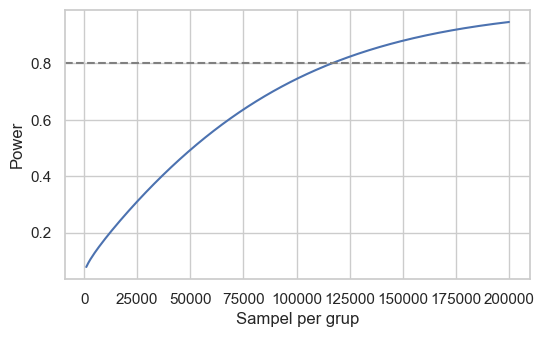

In [17]:
# Kurva power: bagaimana power naik seiring ukuran sampel
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
ns = np.arange(1000, 200_001, 1000)
powers = analysis.power(effect_size=effect_size, nobs1=ns, alpha=0.05, alternative='larger')
plt.figure(figsize=(6, 3.5))
plt.plot(ns, powers)
plt.axhline(0.8, color='grey', ls='--')
plt.xlabel('Sampel per grup')
plt.ylabel('Power')
plt.show()

## Rangkuman Bab 3

- **A/B test** dengan **randomization** adalah cara paling kuat untuk mengukur efek sebuah treatment.
- **Hypothesis test** melindungi kita dari tertipu keacakan. $H_0$ = tidak ada efek.
- **Permutation test** adalah cara intuitif & bebas asumsi untuk menguji signifikansi.
- **p-value** = probabilitas hasil seekstrem ini jika $H_0$ benar — **bukan** probabilitas $H_0$ benar.
- **t-test** adalah aproksimasi berbasis rumus untuk permutation test.
- Banyak uji → **alpha inflation**; gunakan koreksi (Bonferroni, FDR) atau holdout data.
- **ANOVA** untuk >2 grup numerik; **chi-square** untuk data count; **Fisher's exact** untuk count kecil.
- **Multi-arm bandit** mengoptimalkan hasil *selama* eksperimen.
- Hitung **power & sample size** sebelum memulai eksperimen.